# 🔍 EDA complète — Détection de fraude bancaire (v2 enrichie)
**Projet MLOps & DataOps — Livrable EDA (Sprint 1) — Personne 8 (Data Analyst)**

## Contenu
1. [Configuration](#1)
2. [Chargement des données (réelles ou synthétiques)](#2)
3. [Découverte & qualité des données](#3)
4. [Déséquilibre des classes 🚨](#4)
5. [Analyse temporelle approfondie](#5)
6. [Analyse des montants](#6)
7. [Corrélations](#7)
8. [Grille des distributions des 28 features](#8)
9. [Conclusions pour l'équipe](#9)

> ⚙️ **Fonctionne dans tous les cas** : si `creditcard.csv` (Kaggle) est dans le même
> dossier, il est utilisé automatiquement. Sinon, des **données synthétiques réalistes**
> (même structure, mêmes caractéristiques) sont générées pour travailler en attendant.
>
> 📚 *Méthodologie inspirée en partie de l'analyse publique de G. Preda (Kaggle,
> "Credit Card Fraud Detection Predictive Models"), réadaptée, modernisée et étendue
> par notre équipe.*

<a id="1"></a>
## 1️⃣ Configuration

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

os.makedirs("figures", exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

COULEUR_NORMALE = "#2b8cbe"
COULEUR_FRAUDE = "#e34a33"
print("✅ Configuration OK")

✅ Configuration OK


<a id="2"></a>
## 2️⃣ Chargement des données

**Structure du dataset Kaggle** (transactions de cartes bancaires européennes, sept. 2013, 2 jours) :
- `Time` : secondes écoulées depuis la 1ère transaction (~48 h au total)
- `V1` … `V28` : composantes principales issues d'une **ACP** (features anonymisées pour la confidentialité)
- `Amount` : montant de la transaction (seule feature non transformée avec `Time`)
- `Class` : la cible → **0 = normale, 1 = fraude**

In [2]:
def generer_donnees_synthetiques(n=100_000, taux_fraude=0.0017, seed=RANDOM_STATE):
    '''Genere un dataset synthetique imitant creditcard.csv (Kaggle).'''
    rng = np.random.default_rng(seed)
    n_fraude = int(n * taux_fraude)
    n_normal = n - n_fraude

    # TIME : normales surtout en journee (2 jours), fraudes reparties + pic nocturne
    heures_normales = np.concatenate([
        rng.normal(13, 4.0, n_normal // 2),
        rng.normal(13 + 24, 4.0, n_normal - n_normal // 2),
    ]) % 48
    heures_fraude = np.concatenate([
        rng.normal(2, 2.5, int(n_fraude * 0.45)),
        rng.normal(2 + 24, 2.5, int(n_fraude * 0.20)),
        rng.uniform(0, 48, n_fraude - int(n_fraude * 0.45) - int(n_fraude * 0.20)),
    ]) % 48

    # V1..V28 : decalages realistes sur les features connues comme discriminantes
    V_normal = rng.normal(0, 1, size=(n_normal, 28))
    V_fraude = rng.normal(0, 1.4, size=(n_fraude, 28))
    decalages = {14: -6.0, 17: -5.0, 12: -5.5, 10: -4.5, 16: -3.5,
                 3: -4.0, 7: -3.0, 18: -2.5, 11: 3.5, 4: 3.0}
    for v, shift in decalages.items():
        V_fraude[:, v - 1] += shift + rng.normal(0, 1.2, n_fraude)

    # AMOUNT : log-normales ; fraudes plutot petits montants
    amount_normal = np.round(rng.lognormal(3.6, 1.3, n_normal), 2)
    amount_fraude = np.round(rng.lognormal(2.6, 1.6, n_fraude), 2)

    df_n = pd.DataFrame(V_normal, columns=[f"V{i}" for i in range(1, 29)])
    df_n.insert(0, "Time", (heures_normales * 3600).round()); df_n["Amount"] = amount_normal; df_n["Class"] = 0
    df_f = pd.DataFrame(V_fraude, columns=[f"V{i}" for i in range(1, 29)])
    df_f.insert(0, "Time", (heures_fraude * 3600).round()); df_f["Amount"] = amount_fraude; df_f["Class"] = 1

    return pd.concat([df_n, df_f], ignore_index=True).sample(frac=1, random_state=seed).reset_index(drop=True)


CHEMIN_CSV = "creditcard.csv"
if os.path.exists(CHEMIN_CSV):
    df = pd.read_csv(CHEMIN_CSV)
    SOURCE = "RÉEL (Kaggle - creditcard.csv)"
else:
    df = generer_donnees_synthetiques()
    SOURCE = "SYNTHÉTIQUE (généré automatiquement — posez creditcard.csv ici pour utiliser le vrai)"

print(f"📦 Dataset : {SOURCE}")
print(f"   {df.shape[0]:,} transactions × {df.shape[1]} colonnes")
duree_h = (df['Time'].max() - df['Time'].min()) / 3600
print(f"   Période couverte : {duree_h:.0f} heures (~{duree_h/24:.0f} jours)")

📦 Dataset : RÉEL (Kaggle - creditcard.csv)
   284,807 transactions × 31 colonnes
   Période couverte : 48 heures (~2 jours)


<a id="3"></a>
## 3️⃣ Découverte & qualité des données

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df[["Time", "Amount", "Class"]].describe().round(2)

,Time,Amount,Class
count,284807.00,284807.00,284807.00
mean,94813.86,88.35,0.00
std,47488.15,250.12,0.04
min,0.00,0.00,0.00
25%,54201.50,5.60,0.00
50%,84692.00,22.00,0.00
75%,139320.50,77.16,0.00
max,172792.00,25691.16,1.00


### Qualité : valeurs manquantes & doublons
Ces constats alimentent directement le **Data Contract** et les **tests dbt** de P4.

In [5]:
manquantes = df.isnull().sum().sum()
doublons = df.duplicated().sum()
print(f"Valeurs manquantes : {manquantes}")
print(f"Lignes dupliquées  : {doublons}")
if manquantes == 0:
    print("✅ Aucune valeur manquante → test dbt `not_null` sur toutes les colonnes")
if doublons > 0:
    print(f"⚠️ {doublons} doublons ({doublons/len(df)*100:.3f} %) → à dédupliquer dans dbt (couche staging)")
else:
    print("✅ Aucun doublon")

Valeurs manquantes : 0
Lignes dupliquées  : 1081
✅ Aucune valeur manquante → test dbt `not_null` sur toutes les colonnes
⚠️ 1081 doublons (0.380 %) → à dédupliquer dans dbt (couche staging)


<a id="4"></a>
## 4️⃣ 🚨 Déséquilibre des classes — LA découverte clé

Cette information conditionne **toute** la stratégie ML de P6 et le choix des métriques.

Normales :    284,315
Fraudes  :        492  (0.173 %)
Ratio    : 1 fraude pour 577 transactions normales


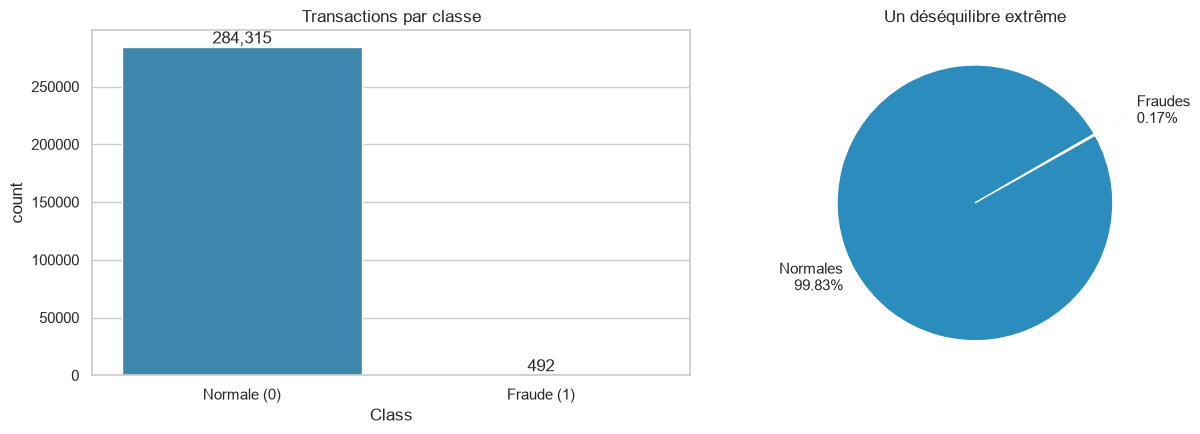

In [6]:
compte = df["Class"].value_counts()
pct = df["Class"].mean() * 100
print(f"Normales : {compte.get(0,0):>10,}")
print(f"Fraudes  : {compte.get(1,0):>10,}  ({pct:.3f} %)")
print(f"Ratio    : 1 fraude pour {int(compte.get(0,0)/max(compte.get(1,1),1)):,} transactions normales")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.countplot(x="Class", data=df, ax=axes[0], hue="Class",
              palette=[COULEUR_NORMALE, COULEUR_FRAUDE], legend=False)
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["Normale (0)", "Fraude (1)"])
axes[0].set_title("Transactions par classe")
for c in axes[0].containers:
    axes[0].bar_label(c, fmt="{:,.0f}")
axes[1].pie([compte.get(0,0), compte.get(1,0)],
            labels=[f"Normales\n{100-pct:.2f}%", f"Fraudes\n{pct:.2f}%"],
            colors=[COULEUR_NORMALE, COULEUR_FRAUDE], explode=(0, 0.25), startangle=30)
axes[1].set_title("Un déséquilibre extrême")
plt.tight_layout()
plt.savefig("figures/01_desequilibre_classes.png", dpi=150, bbox_inches="tight")
plt.show()

> 💡 **Pour P6** : un modèle naïf qui prédit toujours « normale » aurait ~99,8 % d'accuracy
> en ratant 100 % des fraudes. → **SMOTE** ou **`class_weight='balanced'`** obligatoire,
> et métriques = **précision, rappel, F1, AUC-ROC** (jamais l'accuracy seule).
>
> Rappel utile (erreurs de type I et II, adaptées à la fraude) :
> - **Faux positif (type I)** : bloquer une transaction légitime → client mécontent 😠
> - **Faux négatif (type II)** : laisser passer une fraude → argent perdu 💸
> C'est pour équilibrer ces deux coûts qu'on suit précision ET rappel.

<a id="5"></a>
## 5️⃣ Analyse temporelle approfondie

On convertit `Time` (secondes) en **heures écoulées** et en **heure de la journée**, puis
on agrège **par heure et par classe** (nombre, somme, moyenne, médiane des montants).

In [7]:
df["HeureAbs"] = (df["Time"] // 3600).astype(int)      # heure ecoulee depuis le debut (0..47)
df["Heure"] = df["HeureAbs"] % 24                        # heure de la journee (0..23)

# Table d'agregation par heure et par classe (idee reprise de l'analyse Kaggle, modernisee)
agg = (df.groupby(["HeureAbs", "Class"])["Amount"]
         .agg(Transactions="count", Somme="sum", Moyenne="mean", Mediane="median")
         .reset_index())
agg.head(8)

,HeureAbs,Class,Transactions,Somme,Moyenne,Mediane
0,0,0,3961,256572.87,64.774772,12.990
1,0,1,2,529.00,264.500000,264.500
2,1,0,2215,145806.76,65.826980,22.820
3,1,1,2,298.93,149.465000,149.465
4,2,0,1555,106989.39,68.803466,17.900
5,2,1,21,1829.78,87.132381,1.000
6,3,0,1808,94086.79,52.039154,15.950
7,3,1,13,220.05,16.926923,1.000


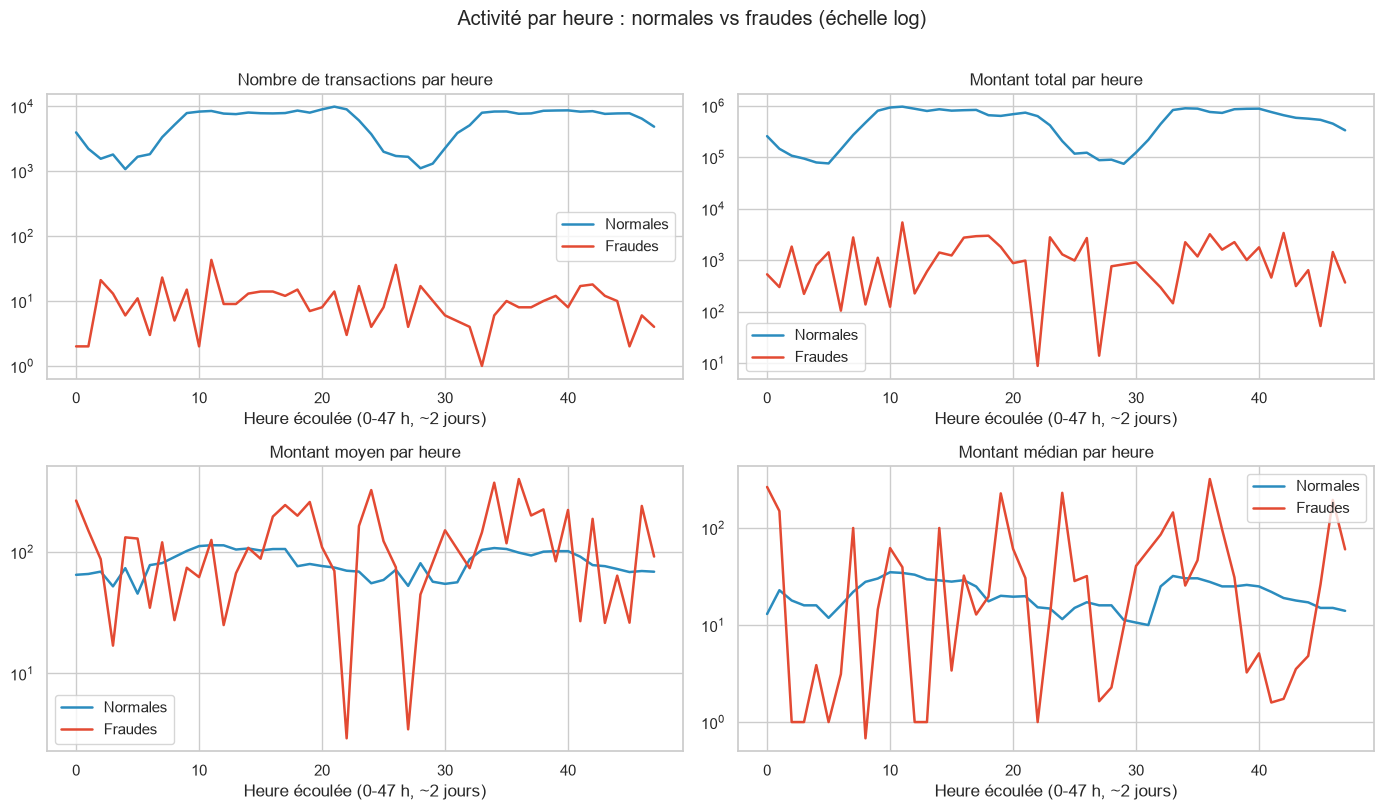

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (col, titre) in zip(axes.ravel(), [
        ("Transactions", "Nombre de transactions par heure"),
        ("Somme", "Montant total par heure"),
        ("Moyenne", "Montant moyen par heure"),
        ("Mediane", "Montant médian par heure")]):
    for classe, couleur, label in [(0, COULEUR_NORMALE, "Normales"), (1, COULEUR_FRAUDE, "Fraudes")]:
        sous = agg[agg["Class"] == classe]
        ax.plot(sous["HeureAbs"], sous[col], color=couleur, label=label, lw=1.8)
    ax.set_title(titre); ax.set_xlabel("Heure écoulée (0-47 h, ~2 jours)")
    ax.legend()
    ax.set_yscale("log")   # echelles tres differentes entre classes

plt.suptitle("Activité par heure : normales vs fraudes (échelle log)", y=1.01)
plt.tight_layout()
plt.savefig("figures/02_agregations_horaires.png", dpi=150, bbox_inches="tight")
plt.show()

**Lecture** : les transactions normales suivent le rythme humain (creux la nuit, pics en
journée) alors que les fraudes sont réparties **plus uniformément** — les fraudeurs ne
dorment pas. Conséquence directe : la **proportion** de fraudes explose la nuit ⤵️

C:\Users\USER\AppData\Local\Temp\ipykernel_1004\4177261270.py:12: UserWarning: Glyph 127769 (\N{CRESCENT MOON}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_1004\4177261270.py:13: UserWarning: Glyph 127769 (\N{CRESCENT MOON}) missing from font(s) Arial.
  plt.savefig("figures/03_taux_fraude_par_heure.png", dpi=150, bbox_inches="tight")
c:\Users\USER\Desktop\fraudguard-mlops\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127769 (\N{CRESCENT MOON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


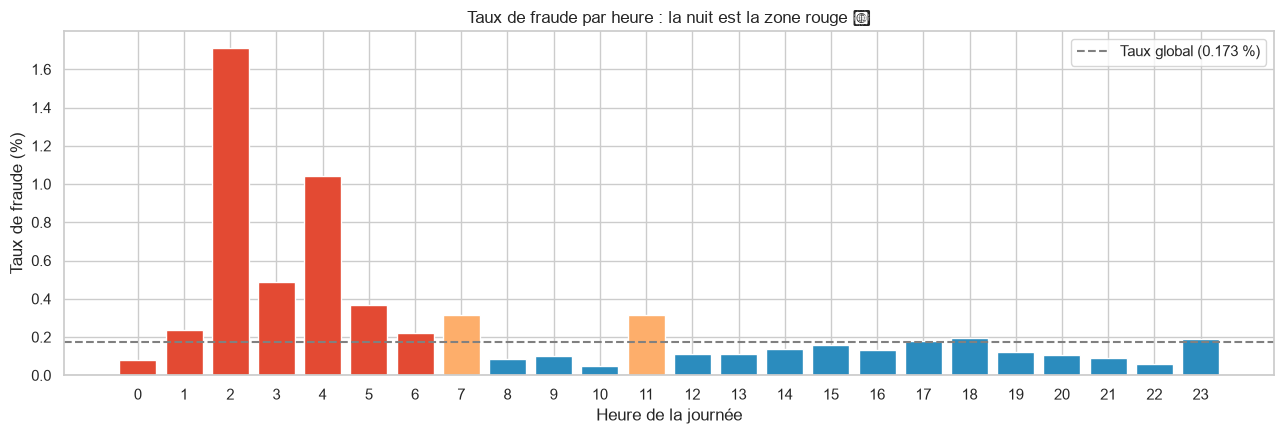

Tranche
Nuit (0-6h)            0.474
Matin (6-12h)          0.153
Après-midi (12-18h)    0.153
Soir (18-24h)          0.109
Name: Taux de fraude (%), dtype: float64


In [9]:
# Taux de fraude par heure de la journee — le graphique le plus parlant
taux_h = df.groupby("Heure")["Class"].mean() * 100

fig, ax = plt.subplots(figsize=(13, 4.5))
couleurs = [COULEUR_FRAUDE if h < 7 else "#fdae6b" if t > taux_h.mean() else COULEUR_NORMALE
            for h, t in taux_h.items()]
ax.bar(taux_h.index, taux_h.values, color=couleurs)
ax.axhline(df["Class"].mean()*100, ls="--", color="gray", label=f"Taux global ({df['Class'].mean()*100:.3f} %)")
ax.set_xlabel("Heure de la journée"); ax.set_ylabel("Taux de fraude (%)")
ax.set_title("Taux de fraude par heure : la nuit est la zone rouge 🌙")
ax.set_xticks(range(0, 24)); ax.legend()
plt.tight_layout()
plt.savefig("figures/03_taux_fraude_par_heure.png", dpi=150, bbox_inches="tight")
plt.show()

df["Tranche"] = pd.cut(df["Heure"], bins=[0, 6, 12, 18, 24], include_lowest=True,
                       labels=["Nuit (0-6h)", "Matin (6-12h)", "Après-midi (12-18h)", "Soir (18-24h)"])
print((df.groupby("Tranche", observed=True)["Class"].mean() * 100).round(3).rename("Taux de fraude (%)"))

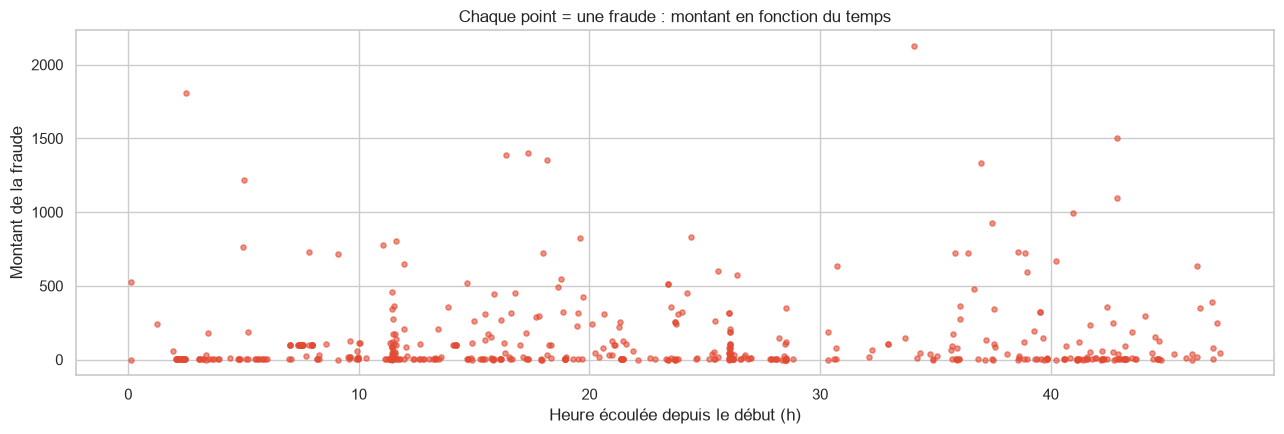

In [10]:
# Montant des fraudes dans le temps (version matplotlib du scatter Plotly du notebook Kaggle)
fraudes = df[df["Class"] == 1]
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.scatter(fraudes["Time"] / 3600, fraudes["Amount"], s=14, alpha=0.6, color=COULEUR_FRAUDE)
ax.set_xlabel("Heure écoulée depuis le début (h)")
ax.set_ylabel("Montant de la fraude")
ax.set_title("Chaque point = une fraude : montant en fonction du temps")
plt.tight_layout()
plt.savefig("figures/04_fraudes_montant_temps.png", dpi=150, bbox_inches="tight")
plt.show()

<a id="6"></a>
## 6️⃣ Analyse des montants

In [11]:
df.groupby("Class")["Amount"].describe().round(2).rename(index={0: "Normale", 1: "Fraude"})

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
Normale,284315.0,88.29,250.11,0.0,5.65,22.00,77.05,25691.16
Fraude,492.0,122.21,256.68,0.0,1.00,9.25,105.89,2125.87


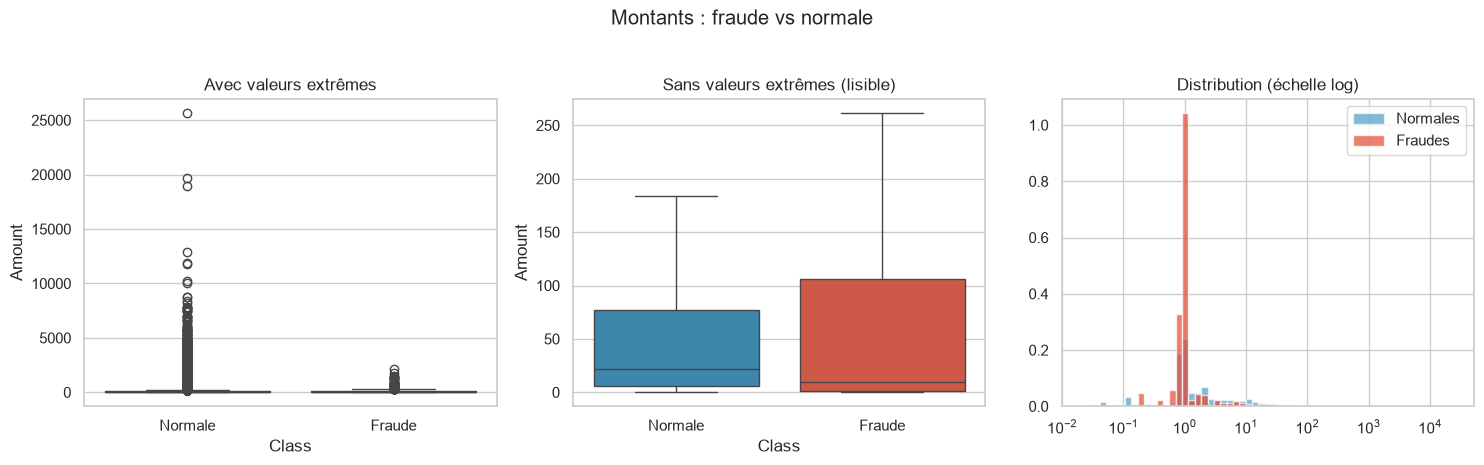

Médiane - Normales :      22.00
Médiane - Fraudes  :       9.25
Max     - Fraudes  :    2125.87


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Boxplot AVEC valeurs extremes
sns.boxplot(x="Class", y="Amount", data=df, ax=axes[0], hue="Class",
            palette=[COULEUR_NORMALE, COULEUR_FRAUDE], legend=False, showfliers=True)
axes[0].set_title("Avec valeurs extrêmes"); axes[0].set_xticks([0,1]); axes[0].set_xticklabels(["Normale", "Fraude"])

# Boxplot SANS valeurs extremes
sns.boxplot(x="Class", y="Amount", data=df, ax=axes[1], hue="Class",
            palette=[COULEUR_NORMALE, COULEUR_FRAUDE], legend=False, showfliers=False)
axes[1].set_title("Sans valeurs extrêmes (lisible)"); axes[1].set_xticks([0,1]); axes[1].set_xticklabels(["Normale", "Fraude"])

# Histogramme echelle log
bins = np.logspace(np.log10(max(df["Amount"].min(), 0.01) + 0.01), np.log10(df["Amount"].max() + 1), 60)
axes[2].hist(df.loc[df.Class == 0, "Amount"], bins=bins, alpha=0.6, density=True,
             color=COULEUR_NORMALE, label="Normales")
axes[2].hist(df.loc[df.Class == 1, "Amount"], bins=bins, alpha=0.7, density=True,
             color=COULEUR_FRAUDE, label="Fraudes")
axes[2].set_xscale("log"); axes[2].set_title("Distribution (échelle log)"); axes[2].legend()

plt.suptitle("Montants : fraude vs normale", y=1.03)
plt.tight_layout()
plt.savefig("figures/05_montants.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Médiane - Normales : {df.loc[df.Class==0,'Amount'].median():>10.2f}")
print(f"Médiane - Fraudes  : {df.loc[df.Class==1,'Amount'].median():>10.2f}")
print(f"Max     - Fraudes  : {df.loc[df.Class==1,'Amount'].max():>10.2f}")

> 💡 **Pour P6** : les fraudes sont majoritairement des **petits montants** (test de carte
> volée) avec quelques exceptions. `Amount` est très asymétrique et sur une échelle
> différente des V1-V28 → **normaliser** (RobustScaler conseillé, robuste aux outliers).

<a id="7"></a>
## 7️⃣ Corrélations

Les V1-V28 viennent d'une ACP → elles sont **décorrélées entre elles** par construction.
Ce qui nous intéresse : leur corrélation avec **Class** (et avec `Amount` / `Time`).

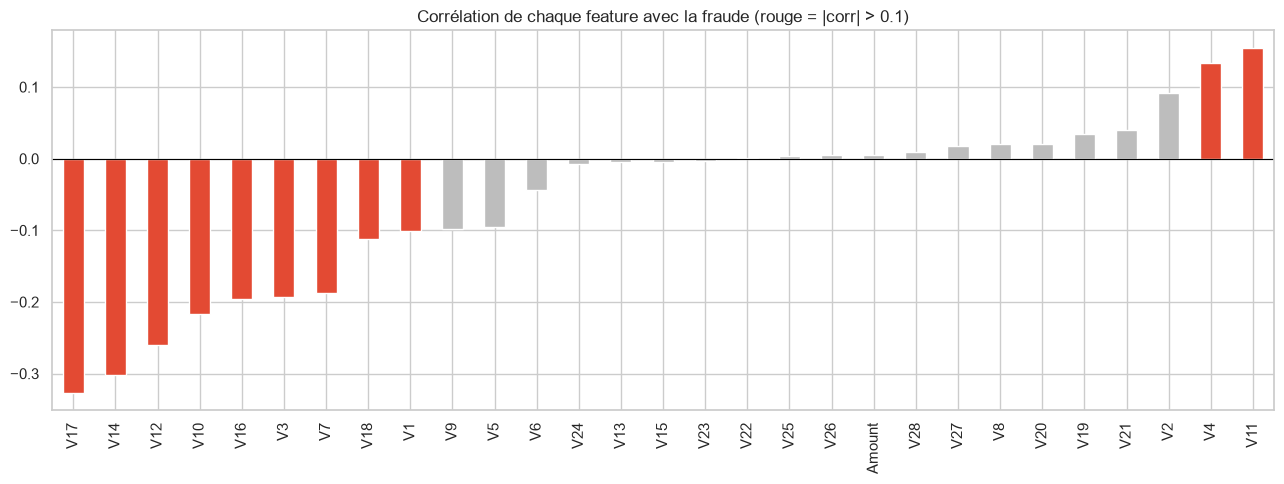

🏆 TOP 8 features les plus corrélées avec la fraude :
   V17      |corr| = 0.326
   V14      |corr| = 0.303
   V12      |corr| = 0.261
   V10      |corr| = 0.217
   V16      |corr| = 0.197
   V3       |corr| = 0.193
   V7       |corr| = 0.187
   V11      |corr| = 0.155


In [13]:
features = [f"V{i}" for i in range(1, 29)] + ["Amount"]
corr_class = df[features + ["Class"]].corr(numeric_only=True)["Class"].drop("Class").sort_values()

fig, ax = plt.subplots(figsize=(13, 5))
couleurs = [COULEUR_FRAUDE if abs(v) > 0.1 else "#bdbdbd" for v in corr_class.values]
corr_class.plot(kind="bar", color=couleurs, ax=ax)
ax.set_title("Corrélation de chaque feature avec la fraude (rouge = |corr| > 0.1)")
ax.axhline(0, color="black", lw=0.8)
plt.tight_layout()
plt.savefig("figures/06_correlations_class.png", dpi=150, bbox_inches="tight")
plt.show()

top = corr_class.abs().sort_values(ascending=False).head(8)
print("🏆 TOP 8 features les plus corrélées avec la fraude :")
for f, v in top.items():
    print(f"   {f:<8} |corr| = {v:.3f}")

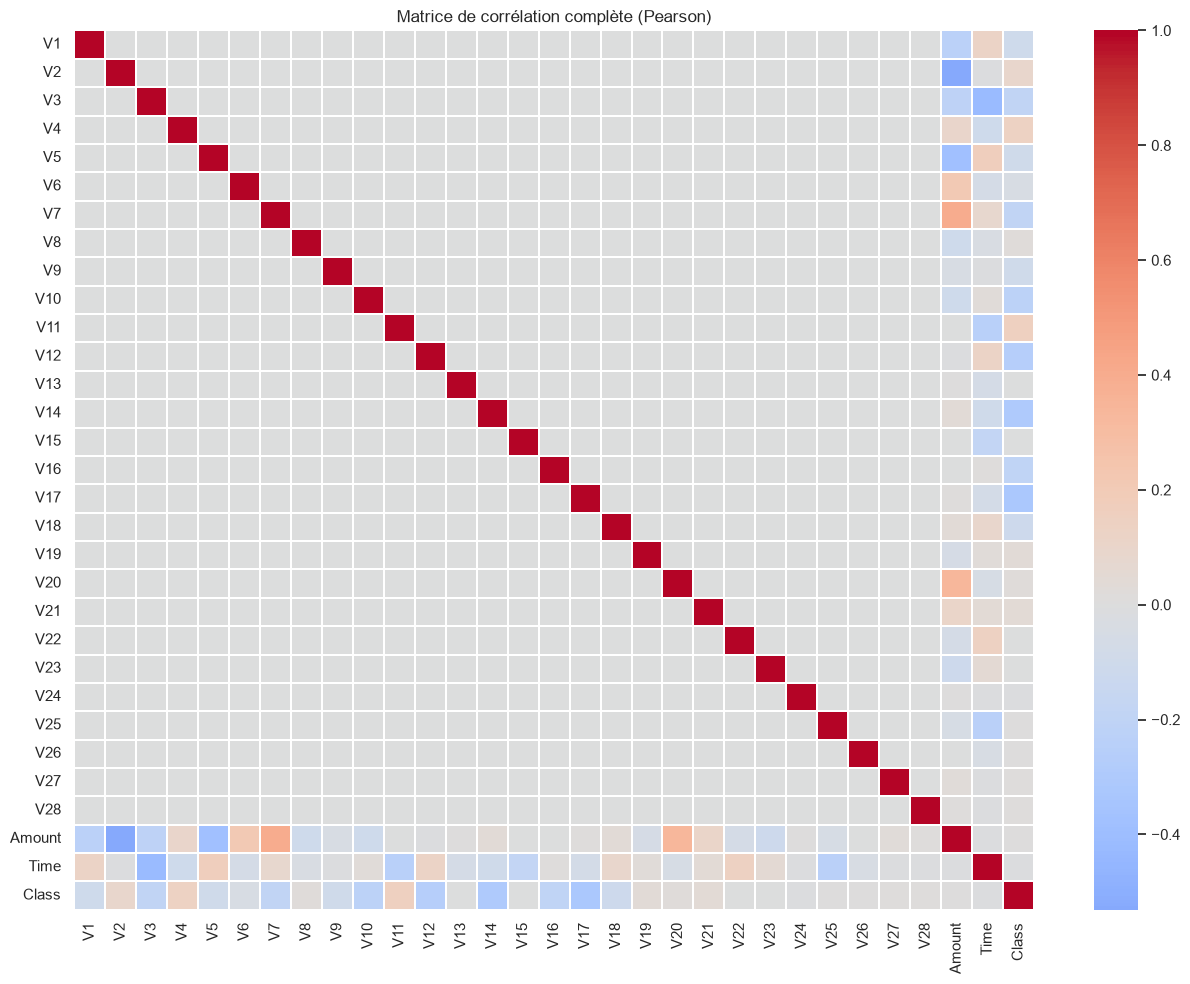

In [14]:
# Heatmap complete (toutes les features) — version moderne de la heatmap du notebook Kaggle
plt.figure(figsize=(13, 10))
sns.heatmap(df[features + ["Time", "Class"]].corr(numeric_only=True),
            cmap="coolwarm", center=0, linewidths=0.1)
plt.title("Matrice de corrélation complète (Pearson)")
plt.tight_layout()
plt.savefig("figures/07_heatmap_complete.png", dpi=150, bbox_inches="tight")
plt.show()

<a id="8"></a>
## 8️⃣ Grille des distributions : les 28 features d'un coup d'œil

Pour chaque feature V1-V28 : densité des transactions **normales** (bleu) vs **fraudes**
(rouge). Plus les deux courbes sont **séparées**, plus la feature est utile au modèle.
*(Idée reprise du notebook Kaggle, modernisée : `bw_adjust`, échantillonnage pour la vitesse.)*

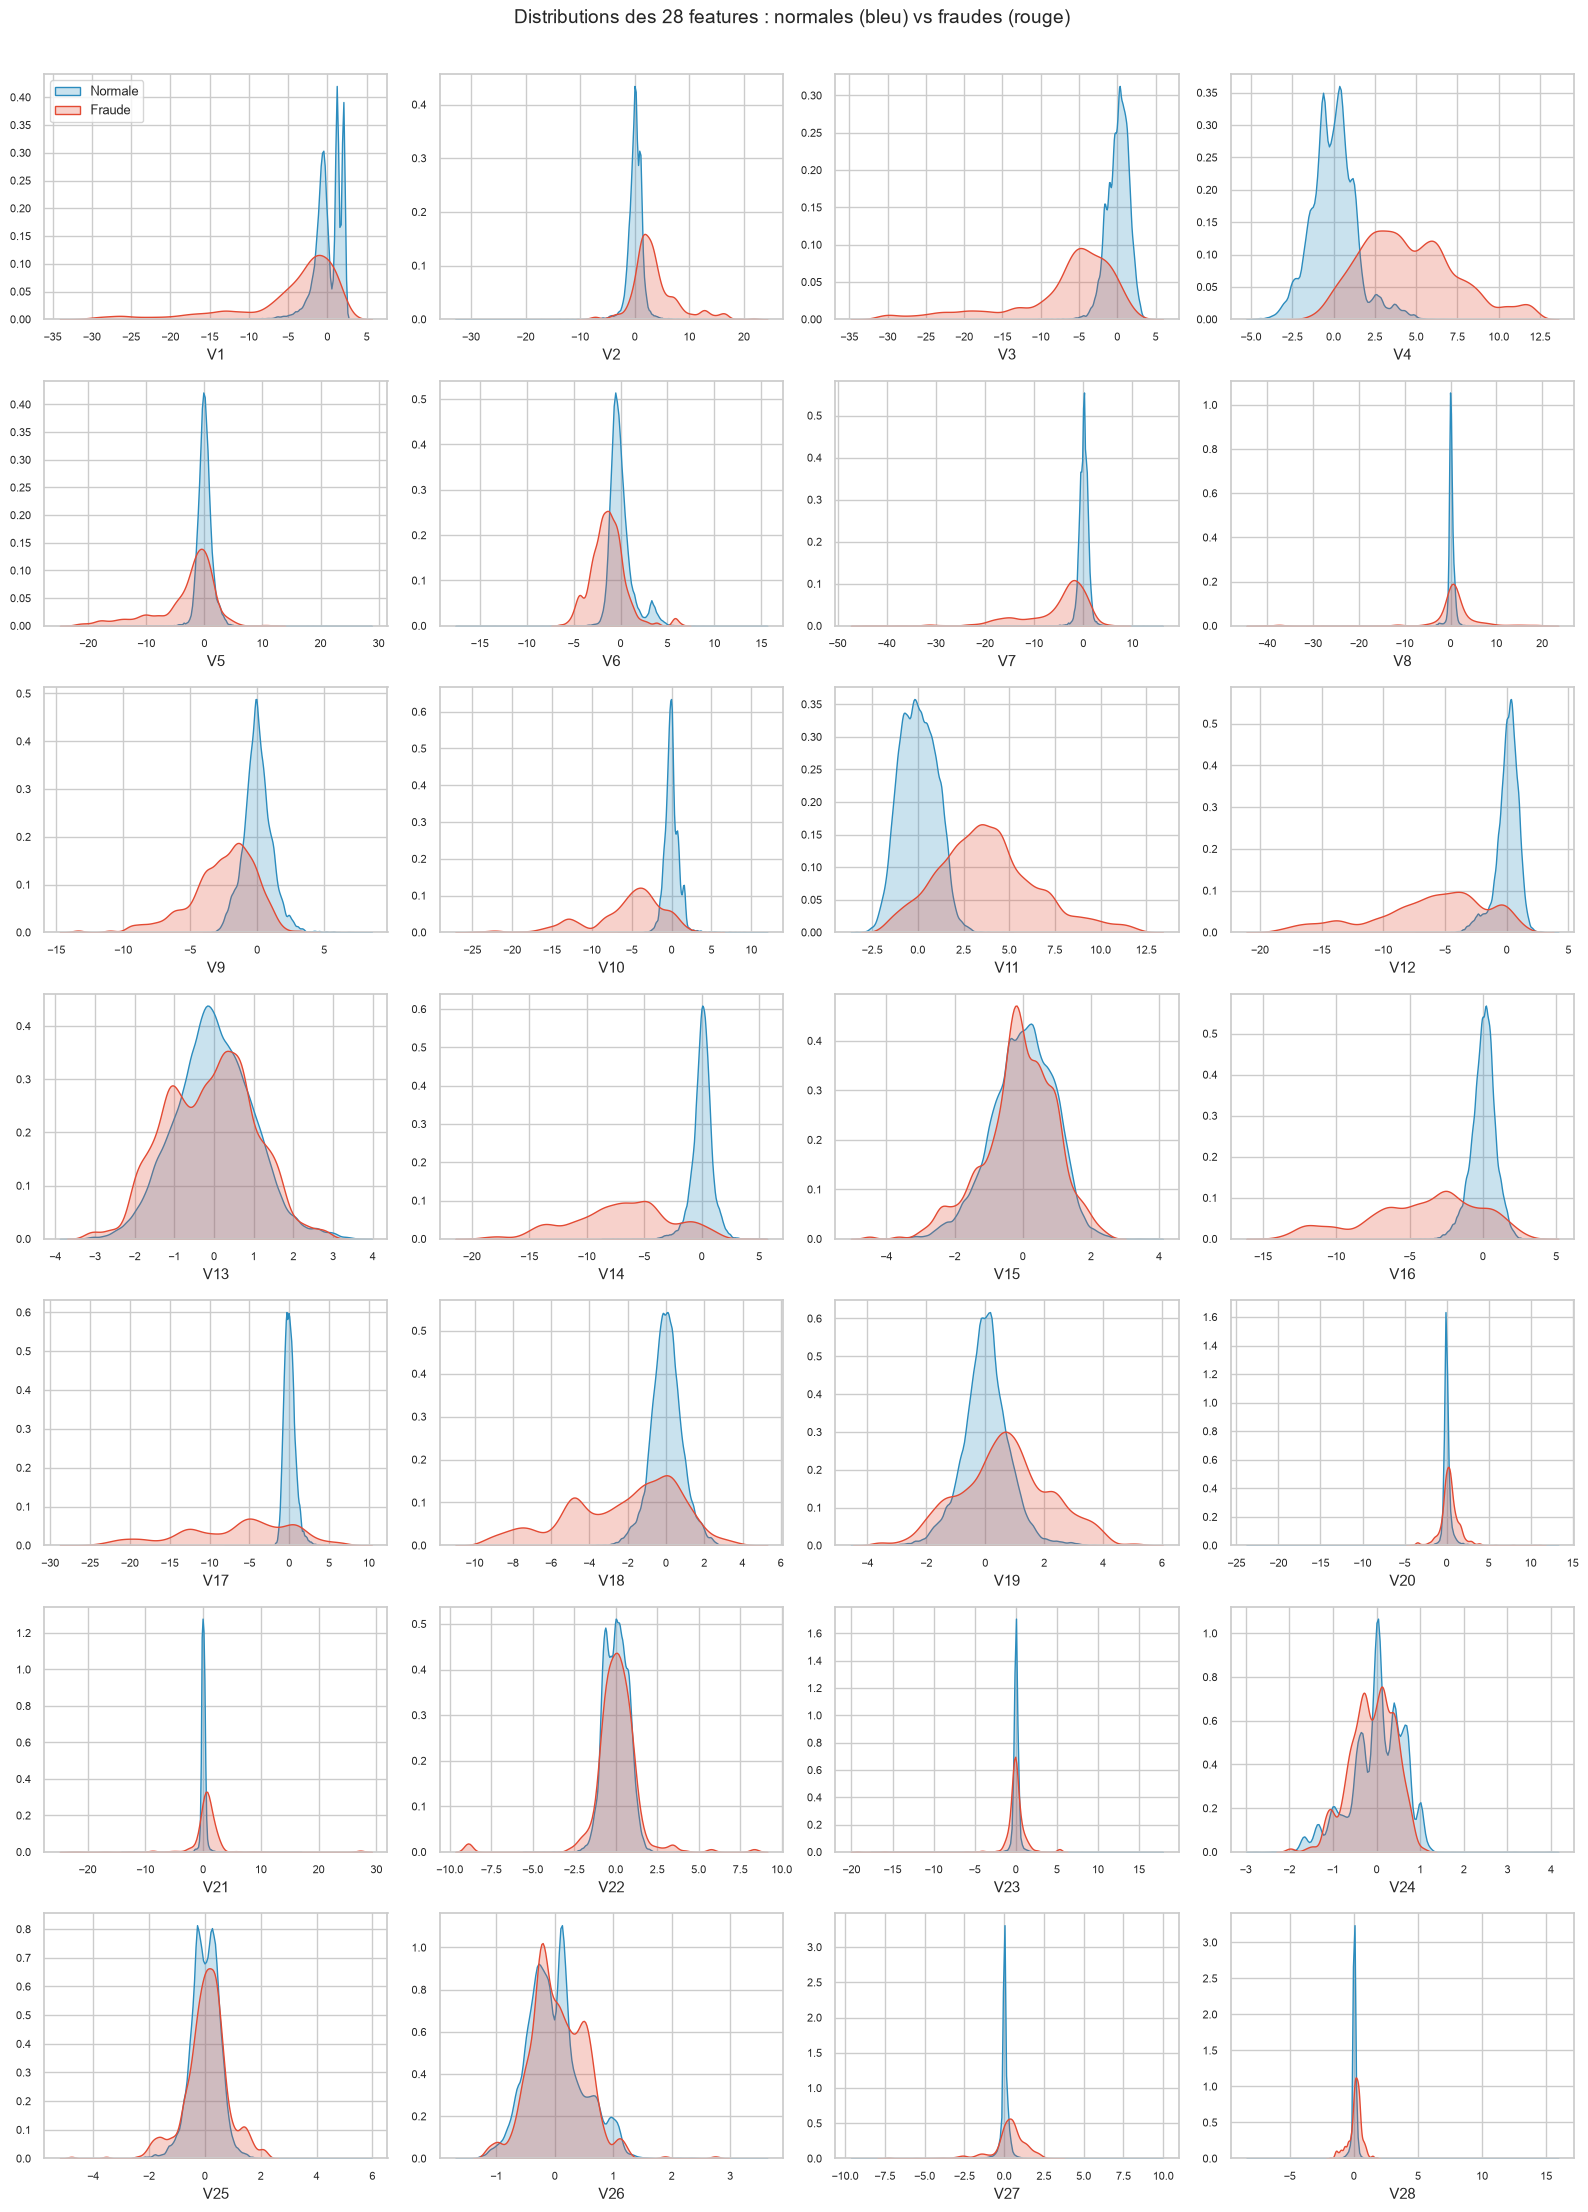

In [15]:
# Echantillonner la classe normale pour accelerer les KDE (tous les points fraude sont gardes)
normales_ech = df[df.Class == 0].sample(min(20_000, (df.Class == 0).sum()), random_state=RANDOM_STATE)
fraudes_all = df[df.Class == 1]

v_features = [f"V{i}" for i in range(1, 29)]
fig, axes = plt.subplots(7, 4, figsize=(16, 22))

for ax, feat in zip(axes.ravel(), v_features):
    sns.kdeplot(normales_ech[feat], ax=ax, color=COULEUR_NORMALE, fill=True, bw_adjust=0.6, label="Normale")
    sns.kdeplot(fraudes_all[feat], ax=ax, color=COULEUR_FRAUDE, fill=True, bw_adjust=0.6, label="Fraude")
    ax.set_xlabel(feat, fontsize=11); ax.set_ylabel("")
    ax.tick_params(labelsize=8)

axes[0, 0].legend(fontsize=9)
plt.suptitle("Distributions des 28 features : normales (bleu) vs fraudes (rouge)", y=1.005, fontsize=14)
plt.tight_layout()
plt.savefig("figures/08_grille_densites_28_features.png", dpi=130, bbox_inches="tight")
plt.show()

**Lecture** : sur le vrai dataset, on observe typiquement que **V4, V11** sont clairement
séparées, **V12, V14, V17, V18** partiellement, tandis que **V25, V26, V28** ont des profils
quasi identiques (peu utiles). Les features des transactions normales sont centrées sur 0 ;
celles des fraudes sont **décalées et asymétriques**.

<a id="9"></a>
## 9️⃣ ✅ Conclusions — à transmettre à l'équipe

| # | Constat | Action | Pour qui |
|---|---------|--------|----------|
| 1 | **Déséquilibre extrême** (~0,17 % de fraudes) | SMOTE ou `class_weight='balanced'` ; métriques = précision, rappel, F1, AUC-ROC | **P6** |
| 2 | **Pas de valeurs manquantes** ; doublons à vérifier | Tests dbt `not_null` + déduplication en staging | **P4** |
| 3 | Fraudes réparties uniformément dans le temps → **taux de fraude explose la nuit (0-6 h)** | Créer la feature `heure` dans dbt ; l'inclure dans le modèle | **P4 + P6** |
| 4 | Fraudes = **petits montants** ; `Amount` très asymétrique | RobustScaler pour `Amount` | **P6** |
| 5 | Features **V14, V17, V12, V10, V11, V4** les plus discriminantes | Les prioriser ; les surveiller en production (dérive) | **P6 + P8** |
| 6 | V25, V26, V28 quasi inutiles | Candidat à une sélection de features | **P6** |

### Suite pour moi (P8)
1. Partager ce notebook + `figures/` via une Pull Request
2. Présenter ces conclusions à la Sprint Review du Sprint 1
3. `reference_drift.csv` (généré ci-dessous) servira de **référence Evidently** pour la
   détection de dérive au Sprint 3

In [17]:
# Echantillon de reference pour le monitoring de derive (Sprint 3, Evidently)
reference = df.drop(columns=["HeureAbs", "Heure", "Tranche"]).sample(min(5000, len(df)), random_state=RANDOM_STATE)
reference.to_csv("reference_drift.csv", index=False)

print("💾 reference_drift.csv sauvegardé (référence pour Evidently au Sprint 3)")
print("💾 Graphiques dans figures/ :")
for f in sorted(os.listdir("figures")):
    print("   -", f)

💾 reference_drift.csv sauvegardé (référence pour Evidently au Sprint 3)
💾 Graphiques dans figures/ :
   - 01_desequilibre_classes.png
   - 02_agregations_horaires.png
   - 03_taux_fraude_par_heure.png
   - 04_fraudes_montant_temps.png
   - 05_montants.png
   - 06_correlations_class.png
   - 07_heatmap_complete.png
   - 08_grille_densites_28_features.png
